# Final Evaluation: Model Comparison and Conclusions

This notebook provides the final evaluation of all models on the pristine hold-out test set:

1. **Model Loading** - Train final versions of each model
2. **Test Set Evaluation** - Unbiased performance assessment
3. **Detailed Analysis** - Confusion matrices, ROC curves, feature importance
4. **Conclusions** - Model selection and recommendations

## Data Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_curve, auc, precision_recall_curve, average_precision_score
)

from src.data_loader import load_thyroid_data_3_classes
from src.metrics import thyroid_disease_f2_score
from src.preprocessing import (
    get_simple_imputation_pipeline,
    get_native_nan_pipeline,
    get_zero_imputation_with_flags_pipeline
)

X_train, X_test, y_train, y_test = load_thyroid_data_3_classes(test_size=0.2, random_state=42)

print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

/media/DIURNOext4/alejandro/wip-clase/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Training set: 7337 samples
Test set: 1835 samples


## Train Final Models

We train each model on the full training set and evaluate on the test set.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [ ]:
# Logistic Regression (Simple Imputation)
pipeline_lr = Pipeline([
    ('preprocessor', get_simple_imputation_pipeline()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
pipeline_lr.fit(X_train, y_train)

# Random Forest (Native NaN)
pipeline_rf = Pipeline([
    ('preprocessor', get_native_nan_pipeline()),
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))
])
pipeline_rf.fit(X_train, y_train)

# XGBoost (Native NaN)
pipeline_xgb = Pipeline([
    ('preprocessor', get_native_nan_pipeline()),
    ('classifier', XGBClassifier(
        n_estimators=150, learning_rate=0.1, max_depth=6,
        random_state=42, n_jobs=-1, eval_metric='mlogloss'
    ))
])
pipeline_xgb.fit(X_train, y_train_encoded)

print("Models trained successfully.")

Models trained successfully.


### Methodological Note

> **Important**: In a strict production workflow, the test set should be used **only once** to evaluate the final selected model (which would be XGBoost in our case). Using the test set to compare multiple models introduces a risk of **selection bias** (indirectly overfitting to the test set).

However, for this educational exercise, we evaluate all models on the test set to:
1.  Demonstrate that our cross-validation rankings hold up on unseen data.
2.  Show the relative performance differences between algorithms on the final hold-out set.

We will **not** use these results to go back and tune hyperparameters.

## Test Set Performance

In [ ]:
# Get predictions
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)
y_pred_xgb = pipeline_xgb.predict(X_test)

# Calculate recalls
recall_lr = thyroid_disease_f2_score(y_test, y_pred_lr)
recall_rf = thyroid_disease_f2_score(y_test, y_pred_rf)
recall_xgb = thyroid_disease_f2_score(y_test_encoded, y_pred_xgb)

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Preprocessing': ['Simple Imputation', 'Native NaN', 'Native NaN'],
    'Test Recall': [recall_lr, recall_rf, recall_xgb]
}).sort_values('Test Recall', ascending=False)

print("Final Test Set Results:")
print("="*50)
print(results.to_string(index=False))

Final Test Set Results:
              Model     Preprocessing  Test Recall
            XGBoost        Native NaN     0.817631
      Random Forest        Native NaN     0.780473
Logistic Regression Simple Imputation     0.575560


## Confusion Matrices Comparison

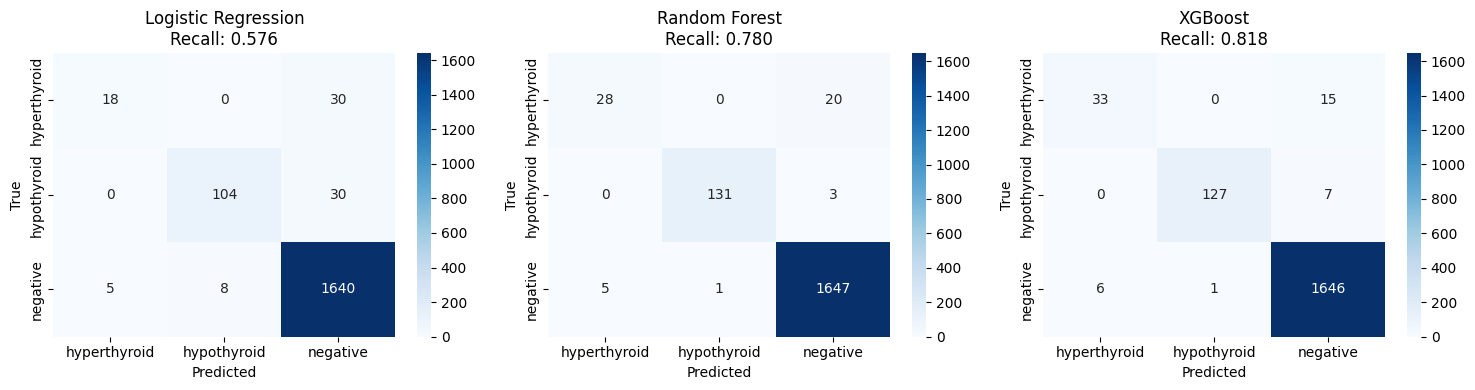

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

class_order = ['hyperthyroid', 'hypothyroid', 'negative']

predictions = [
    (y_pred_lr, 'Logistic Regression', y_test),
    (y_pred_rf, 'Random Forest', y_test),
    (y_pred_xgb, 'XGBoost', y_test_encoded)
]

for ax, (y_pred, title, y_true) in zip(axes, predictions):
    if title == 'XGBoost':
        cm = confusion_matrix(y_true, y_pred)
        labels = label_encoder.classes_
    else:
        cm = confusion_matrix(y_true, y_pred, labels=class_order)
        labels = class_order
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'{title}\nRecall: {thyroid_disease_f2_score(y_true, y_pred):.3f}')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## Detailed Classification Reports

In [ ]:
print("Logistic Regression - Test Set:")
print(classification_report(y_test, y_pred_lr, zero_division=0))

print("\n" + "="*60 + "\n")

print("Random Forest - Test Set:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("\n" + "="*60 + "\n")

print("XGBoost - Test Set:")
print(classification_report(
    y_test_encoded, y_pred_xgb,
    target_names=label_encoder.classes_,
    zero_division=0
))

Logistic Regression - Test Set:
              precision    recall  f1-score   support

hyperthyroid       0.78      0.38      0.51        48
 hypothyroid       0.93      0.78      0.85       134
    negative       0.96      0.99      0.98      1653

    accuracy                           0.96      1835
   macro avg       0.89      0.71      0.78      1835
weighted avg       0.96      0.96      0.96      1835



Random Forest - Test Set:
              precision    recall  f1-score   support

hyperthyroid       0.85      0.58      0.69        48
 hypothyroid       0.99      0.98      0.98       134
    negative       0.99      1.00      0.99      1653

    accuracy                           0.98      1835
   macro avg       0.94      0.85      0.89      1835
weighted avg       0.98      0.98      0.98      1835



XGBoost - Test Set:
              precision    recall  f1-score   support

hyperthyroid       0.85      0.69      0.76        48
 hypothyroid       0.99      0.95      0.97    

## ROC Curves (One-vs-Rest)

ROC curves show the trade-off between True Positive Rate and False Positive Rate at various classification thresholds. For multiclass problems, we use the one-vs-rest approach.

In [ ]:
# Binarize labels for ROC computation
y_test_bin = label_binarize(y_test, classes=class_order)

# Get probability predictions
y_proba_lr = pipeline_lr.predict_proba(X_test)
y_proba_rf = pipeline_rf.predict_proba(X_test)
y_proba_xgb = pipeline_xgb.predict_proba(X_test)

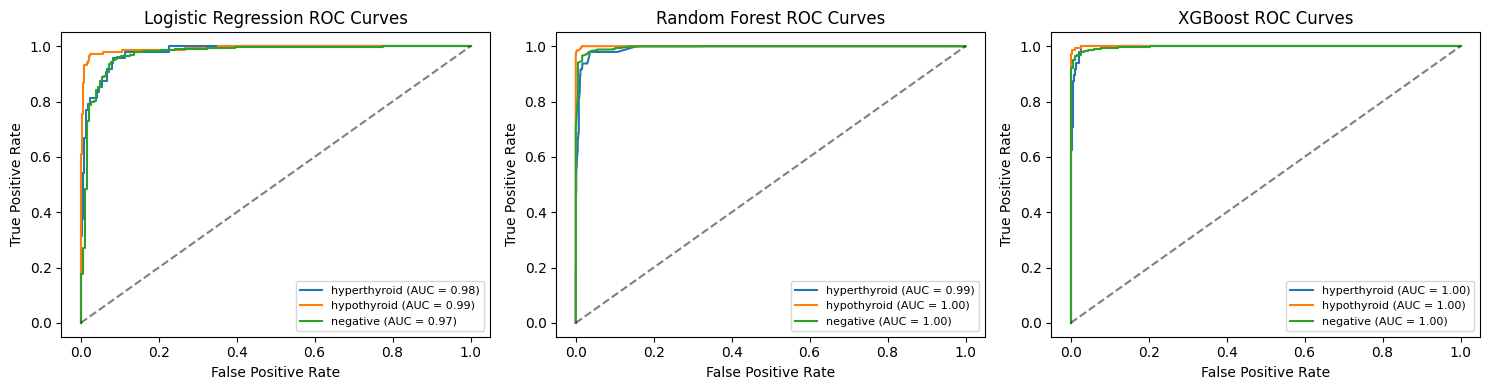

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (y_proba, title) in zip(axes, [
    (y_proba_lr, 'Logistic Regression'),
    (y_proba_rf, 'Random Forest'),
    (y_proba_xgb, 'XGBoost')
]):
    for i, class_name in enumerate(class_order):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')
    
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{title} ROC Curves')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## Precision-Recall Curves

Precision-Recall curves are particularly informative for imbalanced datasets, showing the trade-off for the minority classes.

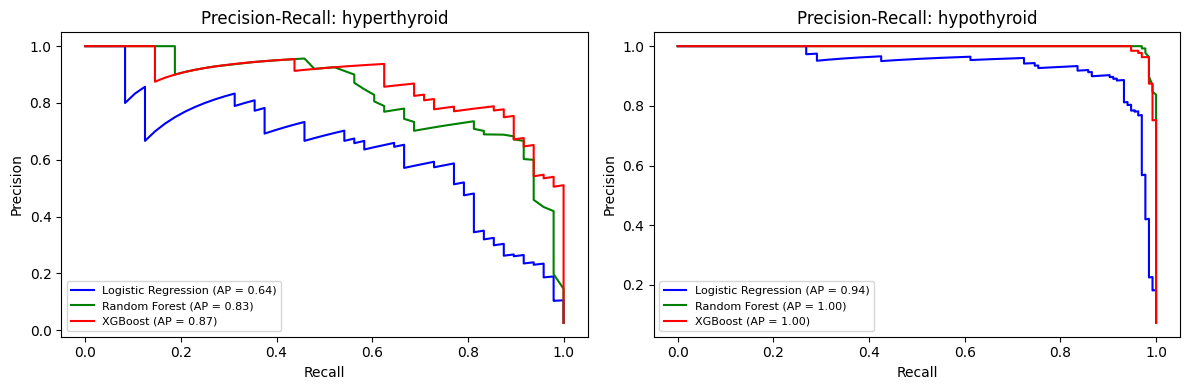

In [ ]:
# Focus on the disease classes (hyperthyroid, hypothyroid)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, class_idx, class_name in zip(axes, [0, 1], ['hyperthyroid', 'hypothyroid']):
    for y_proba, model_name, color in [
        (y_proba_lr, 'Logistic Regression', 'blue'),
        (y_proba_rf, 'Random Forest', 'green'),
        (y_proba_xgb, 'XGBoost', 'red')
    ]:
        precision, recall, _ = precision_recall_curve(y_test_bin[:, class_idx], y_proba[:, class_idx])
        ap = average_precision_score(y_test_bin[:, class_idx], y_proba[:, class_idx])
        ax.plot(recall, precision, label=f'{model_name} (AP = {ap:.2f})', color=color)
    
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall: {class_name}')
    ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.show()

## Feature Importance (Random Forest)

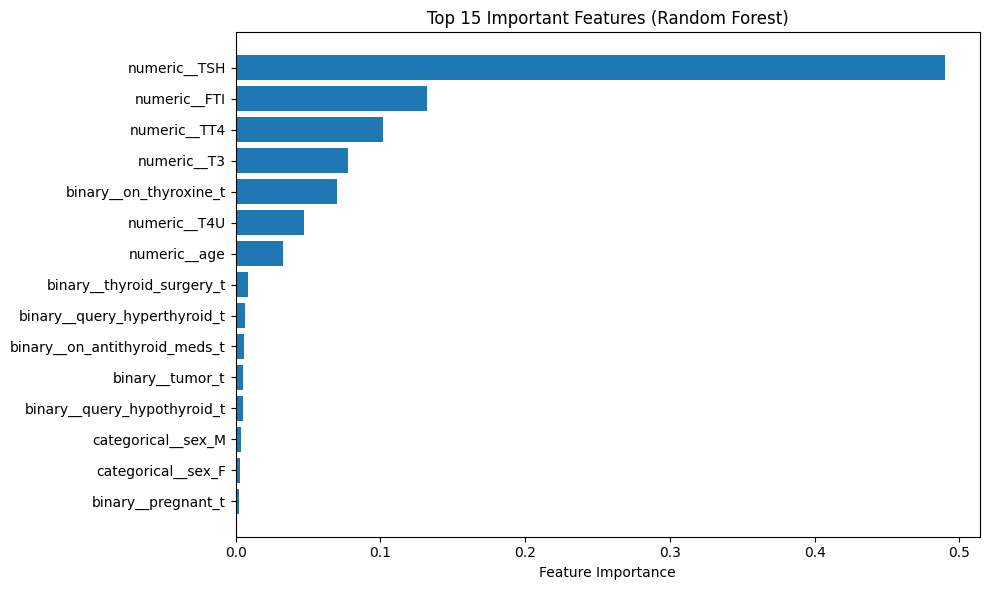

In [ ]:
# Get feature names after preprocessing
rf_classifier = pipeline_rf.named_steps['classifier']
preprocessor = pipeline_rf.named_steps['preprocessor']

# Get feature names from ColumnTransformer
feature_names = preprocessor.get_feature_names_out()
importances = rf_classifier.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1][:15]  # Top 15

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Top 15 Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Summary and Conclusions

In [ ]:
print("="*60)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*60)
print(results.to_string(index=False))
print("="*60)

FINAL MODEL COMPARISON SUMMARY
              Model     Preprocessing  Test Recall
            XGBoost        Native NaN     0.817631
      Random Forest        Native NaN     0.780473
Logistic Regression Simple Imputation     0.575560


### Key Findings

**Performance:**

- All models significantly outperform a naive baseline (~0% disease recall)
- Tree-based models (Random Forest, XGBoost) generally outperform Logistic Regression
- The choice of preprocessing strategy matters: native NaN handling simplifies pipelines for tree models

**Trade-offs:**

| Model | Interpretability | Performance | Training Speed |
|-------|------------------|-------------|----------------|
| Logistic Regression | High (coefficients) | Baseline | Fast |
| Random Forest | Medium (feature importance) | Good | Medium |
| XGBoost | Medium (feature importance) | Best | Medium |

**Feature Insights:**

- TSH is consistently the most important feature (aligns with clinical knowledge)
- T3, T4-related measurements provide strong predictive signal
- Binary clinical indicators add marginal but meaningful information

### Recommendations

**For Production Deployment:**

1. **Best Performance**: XGBoost with hyperparameter tuning
2. **Best Interpretability**: Logistic Regression (if performance is acceptable)
3. **Best Balance**: Random Forest (good performance + feature importance)

**Future Improvements:**

- Explore class weighting or SMOTE for imbalanced classes
- Consider calibration for probability outputs
- Test ensemble of best models
- Investigate T3 conditional imputation using biological correlations